In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Load CovFit model

In [4]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [5]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    
    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)
    
    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]
    
    esm_fine_tuned.load_state_dict(state_dict)
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [7]:
esm_fine_tuned = get_model()

In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [13]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [14]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [15]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [16]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [17]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4404
torch.Size([4404, 1024])


In [18]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [19]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [20]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [21]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [22]:
logit_id = original_task_id_infos["fitness_USA"]

# Curating new fitness with low-mutation dataset

# L455F mutation

In [23]:
N = 455
np.random.seed(20)
num_L_muts = len([x for x in all_uniq_seqs if x[N-1] == "L"])
orig_seq_idx = np.random.permutation(np.arange(num_L_muts))[:200]

orig_idx = list(np.array([x for x in all_uniq_seqs if x[N-1] == "L"])[orig_seq_idx])
new_idx = [x[:N-1] + "F" + x[N:] for x in orig_idx]

In [24]:
# # L455F mutation 
# N = 455

# orig_seq_idx = [i for i,x in enumerate(all_uniq_seqs) if x[N-1] == "L"]

# orig_idx = [x for x in all_uniq_seqs if x[N-1] == "L"][:100]
# new_idx = [x[:N-1] + "F" + x[N:] for x in orig_idx]

# N = 456
# orig_idx = [x for x in all_uniq_seqs if x[N-1] == "F"][:100]
# new_idx = [x[:N-1] + "L" + x[N:] for x in orig_idx][:100]

orig_toks = tokenizer(orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
new_toks = tokenizer(new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [25]:
orig_output = get_logit_hooked(hooked_esm(orig_toks), logit_id)
torch.cuda.empty_cache()
new_output = get_logit_hooked(hooked_esm(new_toks), logit_id)
torch.cuda.empty_cache()

In [26]:
diffs = (new_output - orig_output).cpu().numpy()

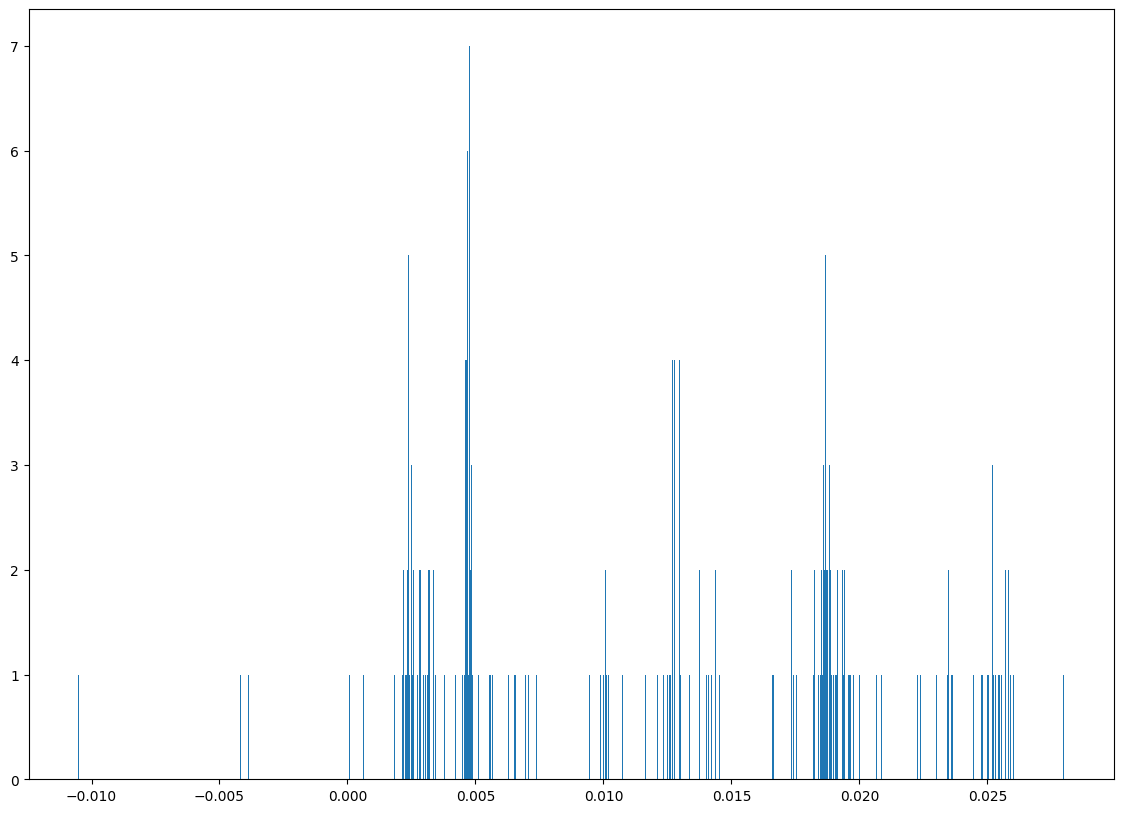

In [27]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(diffs, bins=1000)
# ax.set_xlim([0,0.04])
plt.show()

In [28]:
# del orig_output
# del new_output
# torch.cuda.empty_cache()

# Re-running patching experiments

In [29]:
clean_toks = new_toks
corr_toks = orig_toks

In [30]:
fit_mean_diff_high_low = new_output.mean(dim=0).cpu().numpy() - orig_output.mean(dim=0).cpu().numpy() 

In [31]:
def get_recovery_metrics(clean_out_pred, corr_out_pred):
    clean_perf_recover = 1 - ((new_output - clean_out_pred).abs() / new_output).mean()
    corr_perf_recover = 1 - ((orig_output - corr_out_pred).abs() / orig_output).mean()
    # fit_diff_recover = 1 - np.square((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.square(fit_mean_diff_high_low)
    fit_diff_recover = 1 - np.abs((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.abs(fit_mean_diff_high_low)
    new_diff = (clean_out_pred - corr_out_pred).mean().cpu().numpy()

    return clean_perf_recover, corr_perf_recover, fit_diff_recover, new_diff

# Evaluating Circuit

## Faithfulness

In [32]:
def apply_attn(x: Float[Tensor, "batch seq_len d_model"], layer, pad_tok_mask, attn_mask) -> "batch seq_len n_head d_head":
    hooked_esm.hook_dict["hook_tokens"].ctx["padding_tokens_mask"] = pad_tok_mask
    
    q = einops.einsum(hooked_esm.W_Q[layer], x, "n_head d_model d_head, batch seq_len d_model -> batch seq_len n_head d_head") + hooked_esm.b_Q[layer]
    k = einops.einsum(hooked_esm.W_K[layer], x, "n_head d_model d_head, batch seq_len d_model -> batch seq_len n_head d_head") + hooked_esm.b_K[layer]
    v = einops.einsum(hooked_esm.W_V[layer], x, "n_head d_model d_head, batch seq_len d_model -> batch seq_len n_head d_head") + hooked_esm.b_V[layer]
    
    attn_module = hooked_esm.blocks[layer].attn
    attention_mask = attn_mask
    
    q = attn_module.hook_rot_q(attn_module.apply_rotary(q, 0, attention_mask))  # no offset
    k = attn_module.hook_rot_k(attn_module.apply_rotary(k, 0, attention_mask))  # keys are cached so no offset

    attn_scores = attn_module.calculate_attention_scores(
        q, k
    )  # [batch, head_index, query_pos, key_pos]
    attn_scores = attn_module.hook_attn_scores(attn_scores)
    pattern = F.softmax(attn_scores, dim=-1)
    pattern = torch.where(torch.isnan(pattern), torch.zeros_like(pattern), pattern)
    pattern = attn_module.hook_pattern(pattern)  # [batch, head_index, query_pos, key_pos]
    pattern = pattern.to(attn_module.cfg.dtype)
    pattern = pattern.to(v.device)
    z = attn_module.calculate_z_scores(v, pattern)  # [batch, pos, head_index, d_head]

    return z

In [33]:
def apply_embed(x: Int[Tensor, "batch seq_len"], embed_matrix: Float[Tensor, "d_vocab d_model"]) -> Float[Tensor, "batch seq_len d_model"]:
    return embed_matrix[x,:]

def apply_mlp(x: Float[Tensor, "batch seq_len d_model"], layer_norm, mlp_block):
    return mlp_block(layer_norm(x))

def apply_attn_head(x, layer, layer_norm, head_range, pad_tok_mask, attn_mask):
    x_input = layer_norm(x)
    layer_z = apply_attn(x_input, layer=layer, pad_tok_mask=pad_tok_mask, attn_mask=attn_mask)

    excl_head_range = list(set(range(hooked_esm.cfg.n_heads)) - set(head_range))
    layer_z[:,:,excl_head_range,:] = 0
    return einops.einsum(hooked_esm.W_O[layer], layer_z, "n_head d_head d_model, batch seq_len n_head d_head -> batch seq_len d_model") + hooked_esm.b_O[layer]

In [229]:
def get_attn_mlp_list(toks):
    pad_tok_mask_clean = einops.rearrange(toks == 1, "b sK -> b 1 1 sK")
    attn_mask_clean = utils.get_attention_mask(tokenizer, toks, hooked_esm.cfg.default_prepend_bos)
    mlp_block_list = [functools.partial(apply_mlp, layer_norm=hooked_esm.blocks[layer].ln2, mlp_block=hooked_esm.blocks[layer].mlp) for layer in range(hooked_esm.cfg.n_layers)]
    attn_block_list = [
        functools.partial(
            apply_attn_head, 
            layer=layer,
            layer_norm=hooked_esm.blocks[layer].ln1,
            head_range=list(range(hooked_esm.cfg.n_heads)), 
            pad_tok_mask=pad_tok_mask_clean, 
            attn_mask=attn_mask_clean
        ) for layer in range(hooked_esm.cfg.n_layers)]
    
    attn_block_list[31] = functools.partial(
        apply_attn_head, 
        layer=31,
        layer_norm=hooked_esm.blocks[31].ln1,
        head_range=[1,7,15,17],
        # head_range=[7], 
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    )

    attn_block_list[32] = functools.partial(
        apply_attn_head, 
        layer=32,
        layer_norm=hooked_esm.blocks[32].ln1,
        head_range=[5,8,13], 
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    )

    print(len(attn_block_list), len(mlp_block_list))
    return attn_block_list, mlp_block_list

In [259]:
def get_mod_list(attn_block_list, mlp_block_list):
    N = 1
    module_list = []
    for h_, m_ in zip(attn_block_list[:N], mlp_block_list[:N]):
        module_list.append(h_)
        module_list.append(m_)
    
    # # Prop circuit 3 tweaks from ex25
    # module_list = [
    #     *module_list,
    #     *[mlp_block_list[i] for i in [2,18,19]],
    #     *[mlp_block_list[i] for i in [26,27,28,29,30]],
    #     attn_block_list[31], mlp_block_list[31], 
    #     attn_block_list[32]
    # ]

    # Prop circuit 2
    module_list = [
        attn_block_list[0], mlp_block_list[0], 
        # *[mlp_block_list[i] for i in [11,13,14,17,18,20,21,23,24,26,27]],
        *[mlp_block_list[i] for i in [11,13,14,17,20,21,23,24,26,27]],
        # *[mlp_block_list[i] for i in [7,8,11,13,15,19,23,24,25,26,27]],
        *[mlp_block_list[i] for i in range(28,31,1)], 
        attn_block_list[31], 
        mlp_block_list[31], 
        attn_block_list[32]
    ]

    # # Prop circuit 2 tweaks from ex25
    # module_list = [
    #     attn_block_list[0], mlp_block_list[0], 
    #     *[mlp_block_list[i] for i in [11,13,14,17,18,20,21,23,24]],
    #     *[mlp_block_list[i] for i in range(26,31,1)], 
    #     attn_block_list[31], mlp_block_list[31], 
    #     attn_block_list[32]
    # ]

    print(len(module_list))

    return module_list

In [260]:
def apply_mod_list(toks: Int[Tensor, "batch seq_len"], mod_list):
    x = apply_embed(toks, hooked_esm.W_E)
    for comp_callable in mod_list:
        x = comp_callable(x) + x
    return hooked_esm.ln_final(x)

In [261]:
clean_attn_list, clean_mlp_list = get_attn_mlp_list(clean_toks)
corr_attn_list, corr_mlp_list = get_attn_mlp_list(corr_toks)

clean_mod_list = get_mod_list(clean_attn_list, clean_mlp_list)
corr_mod_list = get_mod_list(corr_attn_list, corr_mlp_list)

33 33
33 33
18
18


In [262]:
pruned_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_mod_list), logit_id)
torch.cuda.empty_cache()
pruned_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_mod_list), logit_id)
torch.cuda.empty_cache()

In [263]:
t1, t2, t3, new_diff = get_recovery_metrics(pruned_clean_fit_preds, pruned_corr_fit_preds)
t1 = t1.cpu().numpy()
t2 = t2.cpu().numpy()

In [264]:
for (n,lab) in zip(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery", "new diff", "actual diff"], [t1, t2, t3, new_diff, fit_mean_diff_high_low]):
    print("%-30s:\t\t%.5f"%(n,lab))

clean fit recovery            :		0.24963
corr. fit recovery            :		0.21802
fit. diff. recovery           :		0.90894
new diff                      :		0.01091
actual diff                   :		0.01200


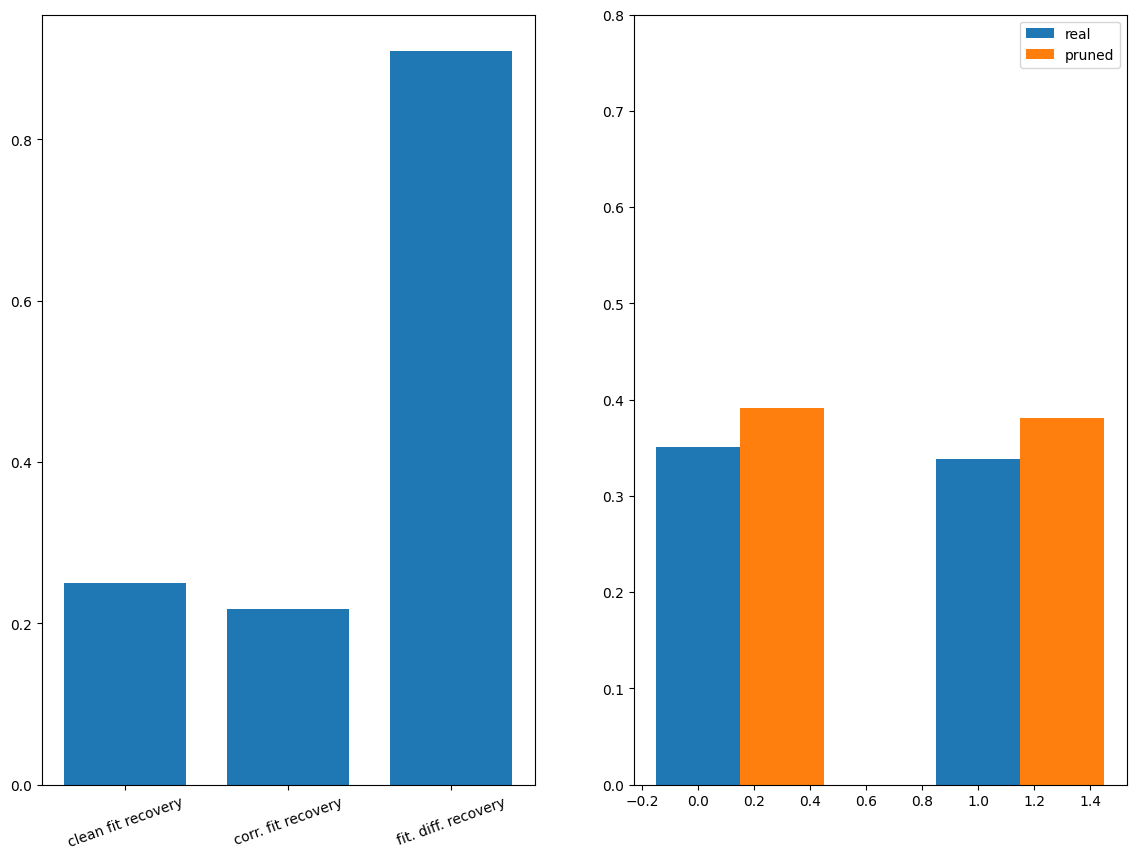

In [265]:
fig, ax = plt.subplots(1,2,figsize=(14,10))
ax[0].bar([i*0.4 for i in range(3)], [t1,t2,t3], width=0.3)
ax[0].set_xticks([i*0.4 for i in range(3)])
ax[0].set_xticklabels(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery"], rotation=20)
ax[1].bar(list(range(2)), [new_output.mean().cpu().numpy(), orig_output.mean().cpu().numpy()],width=0.3, label="real")
ax[1].bar([i+0.3 for i in range(2)], [pruned_clean_fit_preds.mean().cpu().numpy(), pruned_corr_fit_preds.mean().cpu().numpy()], width=0.3, label="pruned")
ax[1].legend()
ax[1].set_ylim([0,0.8])
plt.show()

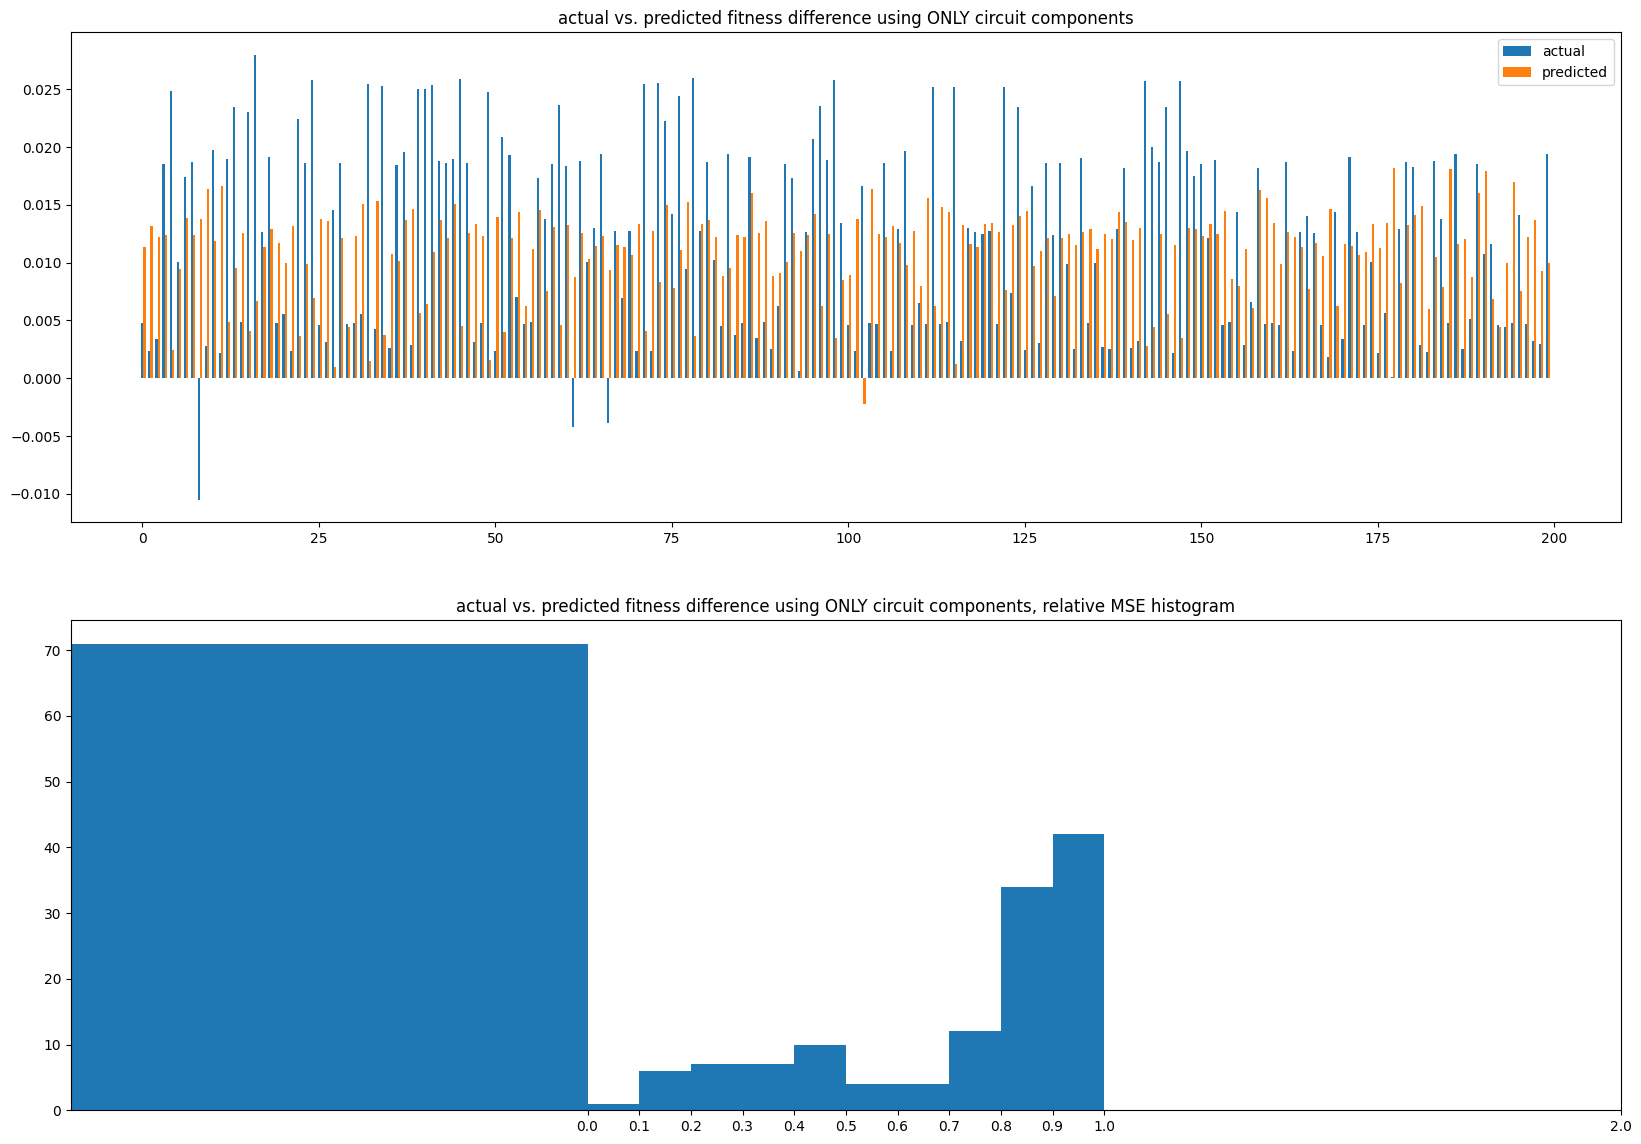

In [266]:
num_data = pruned_clean_fit_preds.shape[0]
predicted_diff = (pruned_clean_fit_preds - pruned_corr_fit_preds).cpu().numpy()
real_diff = (new_output - orig_output).cpu().numpy()

diff_recover_pred = 1 - np.square(predicted_diff -  real_diff) / np.square(real_diff)

fig, ax = plt.subplots(2,1,figsize=(20,14))
ax[0].bar(list(range(num_data)), real_diff,width=0.3, label="actual")
ax[0].bar([i+0.3 for i in range(num_data)], predicted_diff,width=0.3, label="predicted")
ax[0].set_title("actual vs. predicted fitness difference using ONLY circuit components")
ax[0].legend()
# ax[1].hist(diff_recover_pred[np.abs(diff_recover_pred) < 100], width=0.3, bins=200)
ax[1].set_title("actual vs. predicted fitness difference using ONLY circuit components, relative MSE histogram")
hist_bins = [-100, *[i*0.1 for i in range(11)], 2]
ax[1].hist(diff_recover_pred, bins=hist_bins)
ax[1].set_xlim([-1,1])
ax[1].set_xticks(hist_bins[1:])
# ax[1].set_ylim([-4,4])
plt.show()

## Completeness

In [102]:
def rand_subset(
    toks,
    incl_mlp_idx,
    incl_head_idx,
    mlp_list,
    head_layer_list,
    head_list,
    orig_incl_mlp_list,
    orig_incl_head_list
):
    pad_tok_mask_clean = einops.rearrange(toks == 1, "b sK -> b 1 1 sK")
    attn_mask_clean = utils.get_attention_mask(tokenizer, toks, hooked_esm.cfg.default_prepend_bos)

    # CIRC(-UIT) MODULE LIST
    # -------------------------------------
    mlp_mod_comp_list = [
        functools.partial(
            apply_mlp, 
            layer_norm=hooked_esm.blocks[layer].ln2, 
            mlp_block=hooked_esm.blocks[layer].mlp
        ) for layer in incl_mlp_list
    ]

    head_mod_comp_list = [functools.partial(
        apply_attn_head, 
        layer=layer,
        layer_norm=hooked_esm.blocks[layer].ln1,
        head_range=head_range, 
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    ) for layer,head_range in zip(head_layer_list, incl_head_list)]

    l31_idx = (incl_mlp_list < 31).sum()
    circ_module_list = [
        head_mod_comp_list[0],
        *[mlp_mod_comp_list[i] for i in range(l31_idx)],
        head_mod_comp_list[1]
    ]
    if l31_idx < incl_mlp_list.shape[0]:
        circ_module_list.append(mlp_mod_comp_list[-1])
    circ_module_list.append(head_mod_comp_list[2])

    # ORIG MODULE LIST
    # -------------------------------------
    orig_mlp_mod_comp_list = [
        functools.partial(
            apply_mlp, 
            layer_norm=hooked_esm.blocks[layer].ln2, 
            mlp_block=hooked_esm.blocks[layer].mlp
        ) for layer in orig_incl_mlp_list
    ]

    orig_head_mod_comp_list = [functools.partial(
        apply_attn_head, 
        layer=layer,
        layer_norm=hooked_esm.blocks[layer].ln1,
        head_range=list(range(hooked_esm.cfg.n_heads)), 
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    ) for layer in range(hooked_esm.cfg.n_layers)]
    
    for layer, head_range in zip(head_layer_list, orig_incl_head_list):
        orig_head_mod_comp_list[layer] = functools.partial(
                                            apply_attn_head, 
                                            layer=layer,
                                            layer_norm=hooked_esm.blocks[layer].ln1,
                                            head_range=head_range, 
                                            pad_tok_mask=pad_tok_mask_clean, 
                                            attn_mask=attn_mask_clean
                                        )

    orig_module_list = []
    for m_, h_ in zip(orig_mlp_mod_comp_list, orig_head_mod_comp_list):
        orig_module_list.append(h_)
        orig_module_list.append(m_)

    # incl_mlp_list = np.array([0] + list(mlp_list[incl_mlp_idx]))
    # incl_head_list = [head_list[i][incl_head_idx[i]] for i in range(len(incl_head_idx))]
    

    return circ_module_list, orig_module_list

## random subset completeness

In [97]:
mlp_list = np.array([11,13,14,17,18,20,21,23,24] + list(range(26,32,1)))
# mlp_list = np.array([11,13,14,17,20,21,23,24] + list(range(26,32,1)))
head_layer_list = [0,31,32]
head_list = [[i for i in range(hooked_esm.cfg.n_heads)], [7], [5,8,13]]
head_list = [np.array(s) for s in head_list]

In [170]:
true_diffs = []
circ_diffs = []

for i in range(100):
    if i % 10 == 0:
        print()
    print(".",end="")
    # Model = M
    # Get random K subset C
    # incl_mlp_idx = np.full(shape=mlp_list.shape[0], fill_value=True)
    # incl_head_idx = [np.full(shape=s.shape[0], fill_value=True) for s in head_list]
    incl_mlp_idx = np.random.randint(low=0,high=2,size=mlp_list.shape[0]) == 1
    incl_head_idx = [np.random.randint(low=0,high=2,size=s.shape[0]) == 1 for s in head_list]
    
    incl_mlp_list = np.array([0] + list(mlp_list[incl_mlp_idx]))
    incl_head_list = [head_list[i][incl_head_idx[i]] for i in range(len(incl_head_idx))]
    
    orig_incl_mlp_list = list((set(range(hooked_esm.cfg.n_layers)) - set(mlp_list)).union(set(incl_mlp_list)))
    orig_incl_mlp_list.sort()
    orig_incl_head_list = [incl_head_list[0], list(range(7)) + list(incl_head_list[1]) + list(range(8,hooked_esm.cfg.n_heads,1)), list((set(range(hooked_esm.cfg.n_heads)) - set(head_list[2])).union(set(incl_head_list[2])))]
    orig_incl_head_list[-1].sort()

    
    # partial func for M - K, C - K
    apply_rand_subset = functools.partial(
        rand_subset,
        incl_mlp_idx=incl_mlp_idx,
        incl_head_idx=incl_head_idx,
        mlp_list=mlp_list,
        head_layer_list=head_layer_list,
        head_list=head_list,
        orig_incl_mlp_list=orig_incl_mlp_list,
        orig_incl_head_list=orig_incl_head_list
    )
    
    clean_circ_mod_list, clean_orig_mod_list = apply_rand_subset(clean_toks)
    circ_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_circ_mod_list), logit_id)
    torch.cuda.empty_cache()
    true_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_orig_mod_list), logit_id)
    torch.cuda.empty_cache()
    
    corr_circ_mod_list, corr_orig_mod_list = apply_rand_subset(corr_toks)
    circ_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_circ_mod_list), logit_id)
    torch.cuda.empty_cache()
    true_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_orig_mod_list), logit_id)
    torch.cuda.empty_cache()

    true_diffs.append((true_clean_fit_preds - true_corr_fit_preds).mean())
    circ_diffs.append((circ_clean_fit_preds - circ_corr_fit_preds).mean())

print()

# print("included:\n-----------------------")
# print("%-20s:"%"mlp", list(incl_mlp_list))
# print("-----\nhead:")
# for i,h in enumerate(head_layer_list):
#     print("%-20d:"%h, incl_head_list[i])

# print("\norig included:\n-----------------------")
# print("%-20s:"%"mlp", list(orig_incl_mlp_list))
# print("-----\nhead:")
# for i,h in enumerate(head_layer_list):
#     print("%-20d:"%h, orig_incl_head_list[i])


..........
..........
..........
..........
..........
..........
..........
..........
..........
..........


In [171]:
true_diffs_num = [s.item() for s in true_diffs]
circ_diffs_num = [s.item() for s in circ_diffs]

# notable subset completeness

In [98]:
cls_mask = (np.full(shape=mlp_list.shape[0], fill_value=True), [np.full(shape=s.shape[0], fill_value=True) for s in head_list[:-1]] + [np.full(shape=head_list[-1].shape[0], fill_value=False)])
aa455_mask = (np.full(shape=mlp_list.shape[0], fill_value=True), [np.full(shape=s.shape[0], fill_value=True) for s in head_list[0:1]] + [np.array([False])] + [np.full(shape=s.shape[0], fill_value=True) for s in head_list[2:3]])

indiv_mlp_mask = [(np.full(shape=mlp_list.shape[0], fill_value=True), [np.full(shape=s.shape[0], fill_value=True) for s in head_list]) for _ in range(mlp_list.shape[0])]
for i in range(0, mlp_list.shape[0], 1):
    indiv_mlp_mask[i][0][i] = False

In [101]:
cls_mover_completeness = []
aa455_mover_completeness = []
indiv_mlp_completeness = []

for j, (incl_mlp_idx, incl_head_idx) in enumerate([cls_mask, aa455_mask, *indiv_mlp_mask]):
    incl_mlp_list = np.array([0] + list(mlp_list[incl_mlp_idx]))
    incl_head_list = [head_list[i][incl_head_idx[i]] for i in range(len(incl_head_idx))]
    
    orig_incl_mlp_list = list((set(range(hooked_esm.cfg.n_layers)) - set(mlp_list)).union(set(incl_mlp_list)))
    orig_incl_mlp_list.sort()
    orig_incl_head_list = [incl_head_list[0], list(range(7)) + list(incl_head_list[1]) + list(range(8,hooked_esm.cfg.n_heads,1)), list((set(range(hooked_esm.cfg.n_heads)) - set(head_list[2])).union(set(incl_head_list[2])))]
    orig_incl_head_list[-1].sort()

    if j < 2:
        print("included:\n-----------------------")
        print("%-20s:"%"mlp", list(incl_mlp_list))
        print("-----\nhead:")
        for i,h in enumerate(head_layer_list):
            print("%-20d:"%h, incl_head_list[i])
        
        print("\norig included:\n-----------------------")
        print("%-20s:"%"mlp", list(orig_incl_mlp_list))
        print("-----\nhead:")
        for i,h in enumerate(head_layer_list):
            print("%-20d:"%h, orig_incl_head_list[i])
    
    
    # partial func for M - K, C - K
    apply_rand_subset = functools.partial(
        rand_subset,
        incl_mlp_idx=incl_mlp_idx,
        incl_head_idx=incl_head_idx,
        mlp_list=mlp_list,
        head_layer_list=head_layer_list,
        head_list=head_list,
        orig_incl_mlp_list=orig_incl_mlp_list,
        orig_incl_head_list=orig_incl_head_list
    )
    
    clean_circ_mod_list, clean_orig_mod_list = apply_rand_subset(clean_toks)
    circ_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_circ_mod_list), logit_id)
    torch.cuda.empty_cache()
    true_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_orig_mod_list), logit_id)
    torch.cuda.empty_cache()
    
    corr_circ_mod_list, corr_orig_mod_list = apply_rand_subset(corr_toks)
    circ_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_circ_mod_list), logit_id)
    torch.cuda.empty_cache()
    true_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_orig_mod_list), logit_id)
    torch.cuda.empty_cache()

    if j == 0:
        cls_mover_completeness.extend([(circ_clean_fit_preds - circ_corr_fit_preds).mean().item(), (true_clean_fit_preds - true_corr_fit_preds).mean().item()])
    elif j == 1:
        aa455_mover_completeness.extend([(circ_clean_fit_preds - circ_corr_fit_preds).mean().item(), (true_clean_fit_preds - true_corr_fit_preds).mean().item()])
    else:
        indiv_mlp_completeness.append(((circ_clean_fit_preds - circ_corr_fit_preds).mean().item(), (true_clean_fit_preds - true_corr_fit_preds).mean().item()))

In [174]:
print(len(true_diffs_num))

100


In [177]:
mmin = min(min([*true_diffs_num, cls_mover_completeness[1], aa455_mover_completeness[1], *[s[1] for s in indiv_mlp_completeness]]), 
           min([*circ_diffs_num, cls_mover_completeness[0], aa455_mover_completeness[0], *[s[0] for s in indiv_mlp_completeness]])) - 0.001

mmax = max(max([*true_diffs_num, cls_mover_completeness[1], aa455_mover_completeness[1], *[s[1] for s in indiv_mlp_completeness]]), 
           max([*circ_diffs_num, cls_mover_completeness[0], aa455_mover_completeness[0], *[s[0] for s in indiv_mlp_completeness]])) + 0.001

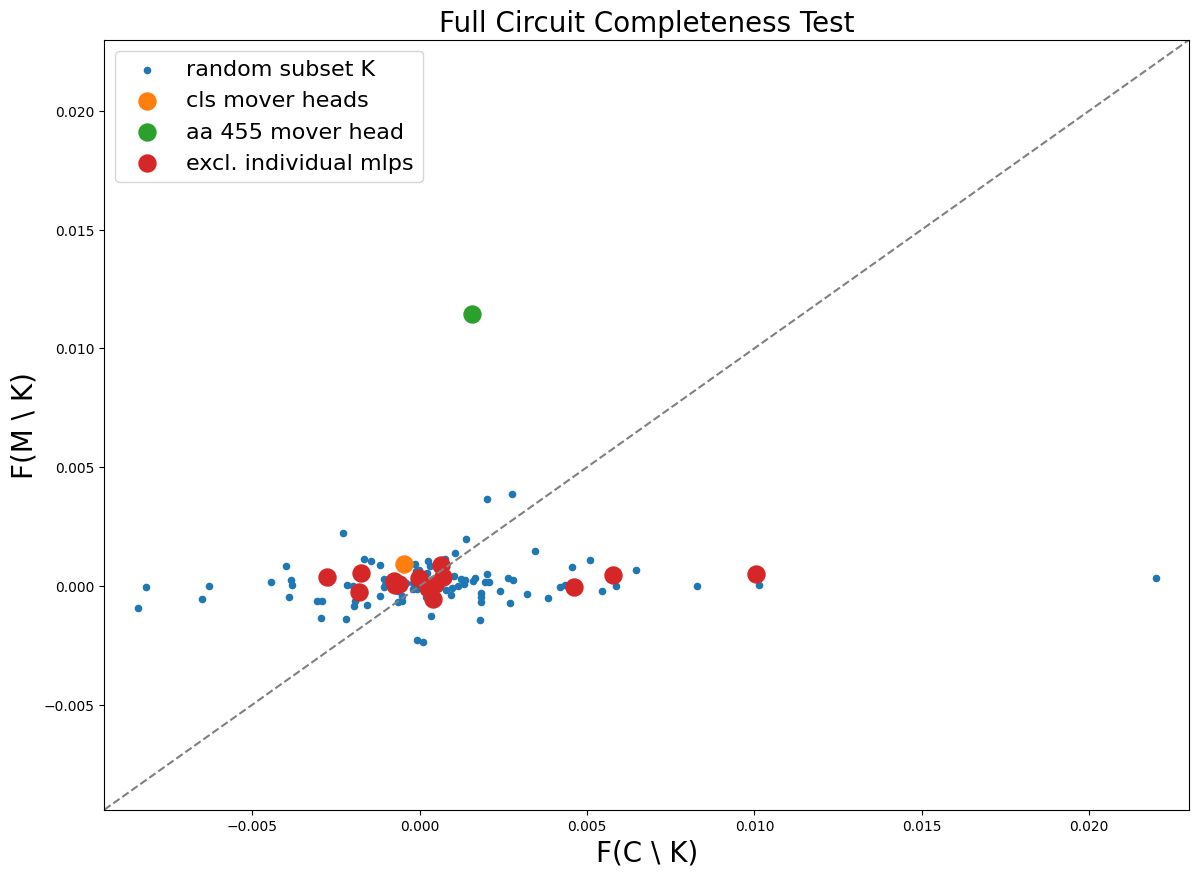

In [178]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.scatter(circ_diffs_num, true_diffs_num, label="random subset K", s=20)

ax.scatter([cls_mover_completeness[0]], [cls_mover_completeness[1]], label="cls mover heads", s=150)
ax.scatter([aa455_mover_completeness[0]], [aa455_mover_completeness[1]], label="aa 455 mover head", s=150)

# nm = 14
# ax.scatter([s[0] for s in indiv_mlp_completeness[nm:nm+1]], [s[1] for s in indiv_mlp_completeness[nm:nm+1]], label="excl. individual mlps", s=150)
ax.scatter([s[0] for s in indiv_mlp_completeness], [s[1] for s in indiv_mlp_completeness], label="excl. individual mlps", s=150)

ax.plot([mmin,mmax],[mmin, mmax], color="gray", linestyle="dashed")
ax.set_xlim([mmin, mmax])
ax.set_ylim([mmin, mmax])
ax.set_ylabel("F(M \\ K)", fontsize=20)
ax.set_xlabel("F(C \\ K)", fontsize=20)
ax.set_title("Full Circuit Completeness Test", fontsize=20)
plt.legend(fontsize=16)
plt.show()

# Remove heads/MLP from full model

In [223]:
def get_attn_mlp_list_full(toks):
    pad_tok_mask_clean = einops.rearrange(toks == 1, "b sK -> b 1 1 sK")
    attn_mask_clean = utils.get_attention_mask(tokenizer, toks, hooked_esm.cfg.default_prepend_bos)
    mlp_block_list = [functools.partial(apply_mlp, layer_norm=hooked_esm.blocks[layer].ln2, mlp_block=hooked_esm.blocks[layer].mlp) for layer in range(hooked_esm.cfg.n_layers)]
    attn_block_list = [
        functools.partial(
            apply_attn_head, 
            layer=layer,
            layer_norm=hooked_esm.blocks[layer].ln1,
            head_range=list(range(hooked_esm.cfg.n_heads)), 
            pad_tok_mask=pad_tok_mask_clean, 
            attn_mask=attn_mask_clean
        ) for layer in range(hooked_esm.cfg.n_layers)]


    # n_ind31 = list(set(range(hooked_esm.cfg.n_heads)) - {1,2,7,8,9,10,12,13,14,15,17})
    # 1,7,15,17
    n_ind31 = list(set(range(hooked_esm.cfg.n_heads)) - {1,7,15,17})
    # n_ind31 = list(range(hooked_esm.cfg.n_heads))
    # n_ind32 = list(set(range(hooked_esm.cfg.n_heads)) - {5,8,13})
    n_ind32 = list(range(hooked_esm.cfg.n_heads))
    
    attn_block_list[31] = functools.partial(
        apply_attn_head, 
        layer=31,
        layer_norm=hooked_esm.blocks[31].ln1,
        head_range=n_ind31,
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    )

    attn_block_list[32] = functools.partial(
        apply_attn_head, 
        layer=32,
        layer_norm=hooked_esm.blocks[32].ln1,
        head_range=n_ind32,
        pad_tok_mask=pad_tok_mask_clean, 
        attn_mask=attn_mask_clean
    )

    print(len(attn_block_list), len(mlp_block_list))
    return attn_block_list, mlp_block_list

In [224]:
def get_mod_list_full(attn_block_list, mlp_block_list):
    N = hooked_esm.cfg.n_layers
    module_list = []
    for h_, m_ in zip(attn_block_list[:N], mlp_block_list[:N]):
        module_list.append(h_)
        module_list.append(m_)

    print(len(module_list))

    return module_list

In [225]:
clean_attn_list, clean_mlp_list = get_attn_mlp_list_full(clean_toks)
corr_attn_list, corr_mlp_list = get_attn_mlp_list_full(corr_toks)

clean_mod_list = get_mod_list_full(clean_attn_list, clean_mlp_list)
corr_mod_list = get_mod_list_full(corr_attn_list, corr_mlp_list)

33 33
33 33
66
66


In [226]:
pruned_clean_fit_preds = get_logit_hooked(apply_mod_list(clean_toks, clean_mod_list), logit_id)
torch.cuda.empty_cache()
pruned_corr_fit_preds = get_logit_hooked(apply_mod_list(corr_toks, corr_mod_list), logit_id)
torch.cuda.empty_cache()

In [227]:
t1, t2, t3, new_diff = get_recovery_metrics(pruned_clean_fit_preds, pruned_corr_fit_preds)
t1 = t1.cpu().numpy()
t2 = t2.cpu().numpy()

In [228]:
for (n,lab) in zip(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery", "new diff", "actual diff"], [t1, t2, t3, new_diff, fit_mean_diff_high_low]):
    print("%-30s:\t\t%.5f"%(n,lab))

clean fit recovery            :		0.69474
corr. fit recovery            :		0.69237
fit. diff. recovery           :		0.47701
new diff                      :		0.00573
actual diff                   :		0.01200


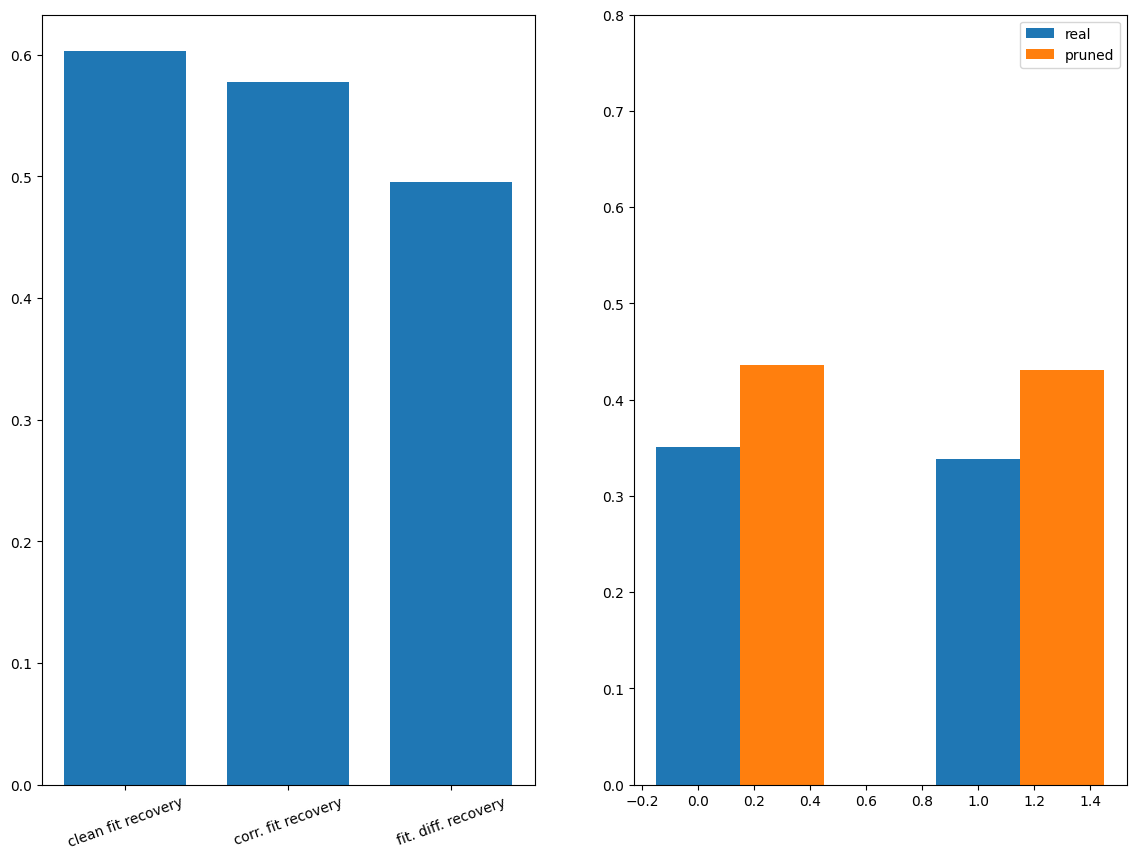

In [91]:
fig, ax = plt.subplots(1,2,figsize=(14,10))
ax[0].bar([i*0.4 for i in range(3)], [t1,t2,t3], width=0.3)
ax[0].set_xticks([i*0.4 for i in range(3)])
ax[0].set_xticklabels(["clean fit recovery", "corr. fit recovery", "fit. diff. recovery"], rotation=20)
ax[1].bar(list(range(2)), [new_output.mean().cpu().numpy(), orig_output.mean().cpu().numpy()],width=0.3, label="real")
ax[1].bar([i+0.3 for i in range(2)], [pruned_clean_fit_preds.mean().cpu().numpy(), pruned_corr_fit_preds.mean().cpu().numpy()], width=0.3, label="pruned")
ax[1].legend()
ax[1].set_ylim([0,0.8])
plt.show()

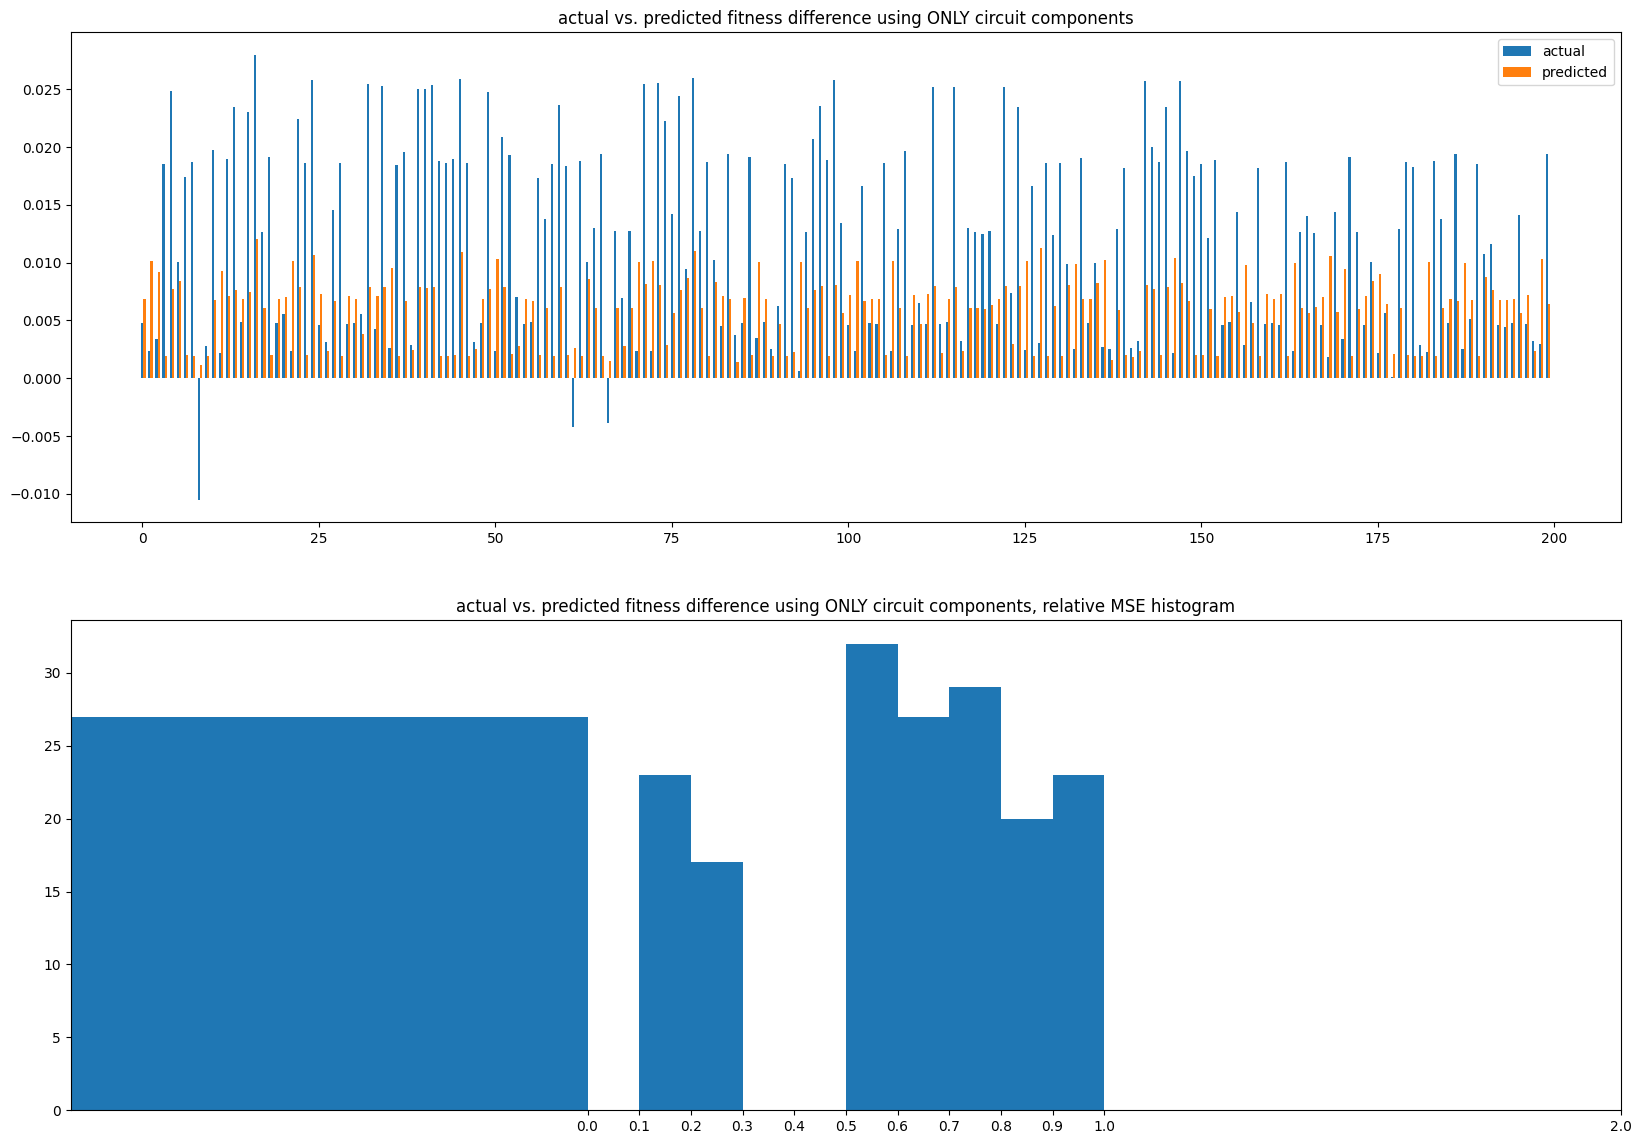

In [92]:
num_data = pruned_clean_fit_preds.shape[0]
predicted_diff = (pruned_clean_fit_preds - pruned_corr_fit_preds).cpu().numpy()
real_diff = (new_output - orig_output).cpu().numpy()

diff_recover_pred = 1 - np.square(predicted_diff -  real_diff) / np.square(real_diff)

fig, ax = plt.subplots(2,1,figsize=(20,14))
ax[0].bar(list(range(num_data)), real_diff,width=0.3, label="actual")
ax[0].bar([i+0.3 for i in range(num_data)], predicted_diff,width=0.3, label="predicted")
ax[0].set_title("actual vs. predicted fitness difference using ONLY circuit components")
ax[0].legend()
# ax[1].hist(diff_recover_pred[np.abs(diff_recover_pred) < 100], width=0.3, bins=200)
ax[1].set_title("actual vs. predicted fitness difference using ONLY circuit components, relative MSE histogram")
hist_bins = [-100, *[i*0.1 for i in range(11)], 2]
ax[1].hist(diff_recover_pred, bins=hist_bins)
ax[1].set_xlim([-1,1])
ax[1].set_xticks(hist_bins[1:])
# ax[1].set_ylim([-4,4])
plt.show()